<a href="https://colab.research.google.com/github/Shahrukh-aidev/machine-learning-journey/blob/main/ML_LAB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Machine Learning — Lab 2
## From Raw Data to ML-Ready Data — Data Cleaning & Exploratory Data Analysis
**Name:** Shahrukh
**Course:** Machine Learning
**Lab:2



In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
#load dataset
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head(10)
df.shape
df.columns
df.info
df.sample(10)



### Initial Dataset Inspection

#The dataset contains 7043 rows and 21 columns.
#The columns represent customer demographics, subscribed services,
#billing/account information, and the target variable Churn.

#The dataset contains both numerical and categorical variables.

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
4958,0060-FUALY,Female,0,Yes,No,59,Yes,Yes,Fiber optic,Yes,Yes,No,No,Yes,No,Month-to-month,Yes,Electronic check,94.75,5597.65,No
1495,4472-VESGY,Female,0,Yes,Yes,52,Yes,Yes,Fiber optic,Yes,Yes,Yes,No,No,Yes,Month-to-month,No,Bank transfer (automatic),98.15,4993.4,No
436,4980-URKXC,Male,0,Yes,No,36,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Bank transfer (automatic),20.85,720.05,No
2682,9462-MJUAW,Male,0,No,No,4,Yes,Yes,DSL,No,No,No,No,No,No,Month-to-month,No,Mailed check,50.40,206.6,Yes
5507,5753-QQWPW,Female,0,No,No,28,Yes,No,DSL,Yes,Yes,No,Yes,No,No,One year,Yes,Electronic check,59.90,1654.7,No
1138,0774-IFUVM,Male,0,Yes,Yes,11,Yes,Yes,DSL,Yes,No,No,No,Yes,No,Month-to-month,Yes,Bank transfer (automatic),65.15,723.35,No
4249,7919-ZODZZ,Female,0,Yes,Yes,10,Yes,No,DSL,No,Yes,Yes,No,No,Yes,One year,Yes,Mailed check,65.90,660.05,No
7018,1122-JWTJW,Male,0,Yes,Yes,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,70.65,70.65,Yes
5038,4815-TUMEQ,Female,0,No,No,10,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.30,185.2,No
1418,9350-VLHMB,Male,0,Yes,Yes,67,Yes,Yes,Fiber optic,No,Yes,No,No,No,Yes,Month-to-month,Yes,Bank transfer (automatic),89.55,6373.1,No


In [6]:
# PART 1 — The Business Problem

### Task 1 — Business Problem

# The telecommunications company is experiencing customer churn,
# meaning customers are leaving the company for competitors.
# The company wants to understand which customer characteristics
# are associated with churn so that it can potentially intervene earlier.

# The likely target variable is `Churn` because it indicates whether
# the customer left the company.



# Task 2 — Predictors and useless columns

## Task 2 — Expected Predictors of Churn

### 5 Potentially Useful Predictors

1. **tenure** — Customers with shorter tenure may be more likely to leave because they have had less time to develop loyalty to the company.

2. **Contract** — Customers on month-to-month contracts may have an easier time leaving than customers on long-term contracts.

3. **MonthlyCharges** — Higher monthly charges may increase the likelihood of customers leaving because they may look for cheaper alternatives.

4. **InternetService** — The type of internet service may affect churn because customers may leave depending on the quality or type of service they receive.

5. **PaymentMethod** — Different payment methods may be associated with different customer behaviors and therefore may help explain churn.

### 2 Potentially Useless Predictors

1. **customerID** — This is only an identifier for each customer and does not describe their behavior or characteristics.

2. **SeniorCitizen** — This is less likely to be useful by itself as a strong predictor because it only indicates whether a customer belongs to the senior-citizen category.

## Task 3 — Questions I Want the Data to Answer

1. Are customers with shorter tenure more likely to churn than customers who have stayed with the company for a longer period?

2. Are customers with higher monthly charges more likely to churn?

In [7]:
# Check the number of customers (rows) and features (columns)

print("Shape of dataset:", df.shape)

print("\nData types:")
print(df.dtypes)

print("\nNumerical features:")
print(df.select_dtypes(include='number').columns.tolist())

print("\nCategorical features:")
print(df.select_dtypes(include='object').columns.tolist())

Shape of dataset: (7043, 21)

Data types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges']

Categorical features:
['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharge

## Task 1 — Dataset Structure

The dataset contains **7,043 customers** and **21 columns/features**.

### Numerical Features
- SeniorCitizen
- tenure
- MonthlyCharges

### Categorical Features
- customerID
- gender
- Partner
- Dependents
- PhoneService
- MultipleLines
- InternetService
- OnlineSecurity
- OnlineBackup
- DeviceProtection
- TechSupport
- StreamingTV
- StreamingMovies
- Contract
- PaperlessBilling
- PaymentMethod
- TotalCharges
- Churn

The `customerID` column is an identifier rather than a predictive feature. Also, `TotalCharges` is currently stored as an object/categorical type even though it represents a numerical amount, so its data type should be investigated.


## Task 2 — Identifiers and Incorrect Data Types

### Identifier Column

- **customerID** — This column is simply a unique identifier for each customer. It does not represent a customer characteristic or behavior, so it is not expected to be useful as a predictive feature.

### Column With a Questionable Data Type

- **TotalCharges** — This column represents the total amount charged to a customer, so it should logically be numerical. However, Pandas currently identifies it as `object`, suggesting that some values may contain spaces or other non-numeric entries.


In [13]:
print("Gender:")
print(df['gender'].unique())

print("\nContract:")
print(df['Contract'].unique())

print("\nInternetService:")
print(df['InternetService'].unique())

Gender:
['Female' 'Male']

Contract:
['Month-to-month' 'One year' 'Two year']

InternetService:
['DSL' 'Fiber optic' 'No']


## Task 3 — Categorical Features and Unique Values

### 1. gender
Unique values:
- Female
- Male

No unexpected or inconsistently formatted categories were found.

### 2. Contract
Unique values:
- Month-to-month
- One year
- Two year

No unexpected or inconsistently formatted categories were found.

### 3. InternetService
Unique values:
- DSL
- Fiber optic
- No

No unexpected or inconsistently formatted categories were found.

Overall, the three categorical columns contain clear and consistent categories. No obvious spelling differences, extra spaces, or duplicate representations of the same category were observed.


In [14]:
# Missing values count
missing_count = df.isnull().sum()

# Missing values percentage
missing_percentage = (df.isnull().mean() * 100)

# Combine both into one table
missing_summary = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing Percentage': missing_percentage
})

# Show only columns that have missing values
missing_summary[missing_summary['Missing Count'] > 0]

,Missing Count,Missing Percentage


In [10]:
# Check for blank or whitespace-only values in each column
blank_values = {}

for col in df.columns:
    blank_count = df[col].astype(str).str.strip().eq('').sum()
    if blank_count > 0:
        blank_values[col] = blank_count

blank_values

{'TotalCharges': np.int64(11)}

## Task 4 — Missing Values

The initial `df.isnull().sum()` check showed no missing values represented as `NaN`.

However, after checking for blank or whitespace-only values, I found **11 missing values in the `TotalCharges` column**. These represent approximately **0.16% of the 7,043 customer records**.

The missing values in `TotalCharges` require action because `TotalCharges` is an important numerical billing feature, and the blank values also explain why the column was stored as an `object` data type instead of a numerical type.

No other columns were found to contain blank or whitespace-only values.

In [11]:
# Check for completely duplicated rows
duplicate_rows = df.duplicated().sum()

# Check for duplicated customer IDs
duplicate_customer_ids = df['customerID'].duplicated().sum()

print("Duplicate rows:", duplicate_rows)
print("Duplicate customer IDs:", duplicate_customer_ids)

Duplicate rows: 0
Duplicate customer IDs: 0


## Task 5 — Duplicate Rows and Duplicate Customer IDs

The dataset contains **0 completely duplicated rows** and **0 duplicated customer IDs**.

Therefore, there is no evidence of duplicate records or repeated customer identifiers in the dataset. These are related but different checks: duplicate rows mean the entire record is repeated, while duplicate customer IDs mean the same customer identifier appears more than once.

In [12]:
print("TotalCharges data type:", df['TotalCharges'].dtype)

print("\nBlank TotalCharges values:")
print(df[df['TotalCharges'].astype(str).str.strip() == ''][['customerID', 'TotalCharges']])

TotalCharges data type: object

Blank TotalCharges values:
      customerID TotalCharges
488   4472-LVYGI             
753   3115-CZMZD             
936   5709-LVOEQ             
1082  4367-NUYAO             
1340  1371-DWPAZ             
3331  7644-OMVMY             
3826  3213-VVOLG             
4380  2520-SGTTA             
5218  2923-ARZLG             
6670  4075-WKNIU             
6754  2775-SEFEE             


## Task 6 — Suspicious or Invalid Values

The `TotalCharges` column contains suspicious values. Although it represents a numerical billing amount, its data type is `object` instead of numeric.

I found this issue by checking the data type of `TotalCharges` and then searching for blank or whitespace-only values. This revealed **11 blank values** in the column. These blank values are likely the reason the column was stored as `object` and will need to be handled during data cleaning.


## Part 4 — Data Cleaning Decisions
### Task 10 — Cleaning Decisions

| Problem | Decision | Method Used | Reason |
|---|---|---|---|
| `TotalCharges` is stored as `object` although it represents a numerical billing amount. | Convert `TotalCharges` to numeric. | `pd.to_numeric(df['TotalCharges'], errors='coerce')` | `TotalCharges` represents a monetary amount, so it should be stored as a numeric variable for analysis and future ML preprocessing. |
| `TotalCharges` contains 11 blank values, and all affected customers have `tenure = 0`. | Replace the blank `TotalCharges` values with `0`. | Convert blanks to `NaN` using `pd.to_numeric(..., errors='coerce')`, then use `fillna(0)`. | All 11 affected customers have zero tenure, so they have not accumulated previous charges. Setting their total charges to 0 preserves these valid customer records instead of deleting them or using an unrelated statistical value such as the mean or median. |
| No completely duplicated rows were found. | Keep all rows; do not remove duplicates. | `df.duplicated().sum()` | The result is 0, so there are no duplicate rows to remove. |
| No duplicate `customerID` values were found. | Keep all records with respect to duplicate IDs. | `df['customerID'].duplicated().sum()` | The result is 0, so no customer identifier appears more than once. |

In [15]:
# Inspect the customers with blank TotalCharges
df.loc[
    df['TotalCharges'].astype(str).str.strip() == '',
    ['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']
]

,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,
753,3115-CZMZD,0,20.25,
936,5709-LVOEQ,0,80.85,
1082,4367-NUYAO,0,25.75,
1340,1371-DWPAZ,0,56.05,
3331,7644-OMVMY,0,19.85,
3826,3213-VVOLG,0,25.35,
4380,2520-SGTTA,0,20.00,
5218,2923-ARZLG,0,19.70,
6670,4075-WKNIU,0,73.35,


In [16]:
# Create an intermediate cleaned dataframe
cleaned_df = df.copy()

# Convert TotalCharges to numeric.
# Blank values become NaN.
cleaned_df['TotalCharges'] = pd.to_numeric(
    cleaned_df['TotalCharges'],
    errors='coerce'
)

# The 11 missing TotalCharges values belong to customers with tenure = 0,
# so we treat their total charges as 0.
cleaned_df['TotalCharges'] = cleaned_df['TotalCharges'].fillna(0)

# Confirm the data type and remaining missing values
print("TotalCharges data type:", cleaned_df['TotalCharges'].dtype)
print("\nMissing TotalCharges values:", cleaned_df['TotalCharges'].isnull().sum())

# Confirm there are still no duplicates
print("Duplicate rows:", cleaned_df.duplicated().sum())
print("Duplicate customer IDs:",
      cleaned_df['customerID'].duplicated().sum())

TotalCharges data type: float64

Missing TotalCharges values: 0
Duplicate rows: 0
Duplicate customer IDs: 0


In [17]:
# Check the cleaned TotalCharges values for the previously blank customers
cleaned_df.loc[
    df['TotalCharges'].astype(str).str.strip() == '',
    ['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']
]

,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,0.0
753,3115-CZMZD,0,20.25,0.0
936,5709-LVOEQ,0,80.85,0.0
1082,4367-NUYAO,0,25.75,0.0
1340,1371-DWPAZ,0,56.05,0.0
3331,7644-OMVMY,0,19.85,0.0
3826,3213-VVOLG,0,25.35,0.0
4380,2520-SGTTA,0,20.00,0.0
5218,2923-ARZLG,0,19.70,0.0
6670,4075-WKNIU,0,73.35,0.0


Part 5 — Univariate EDA

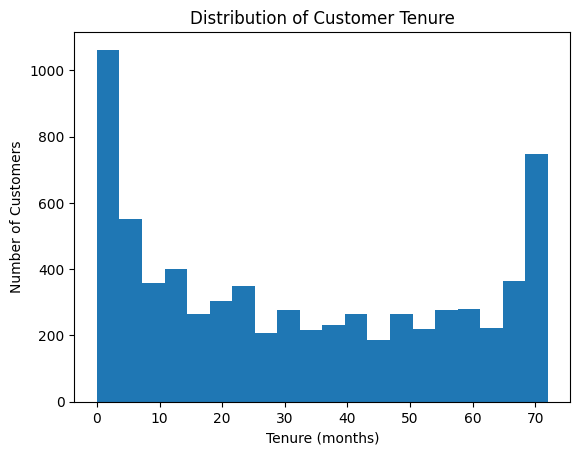

In [18]:
import matplotlib.pyplot as plt

cleaned_df['tenure'].plot(kind='hist', bins=20)

plt.title('Distribution of Customer Tenure')
plt.xlabel('Tenure (months)')
plt.ylabel('Number of Customers')
plt.show()

**Interpretation:**  
The tenure distribution shows how long customers have remained with the company. The distribution should be examined for concentration at lower or higher tenure values, which can indicate whether the dataset contains more newer or longer-term customers.

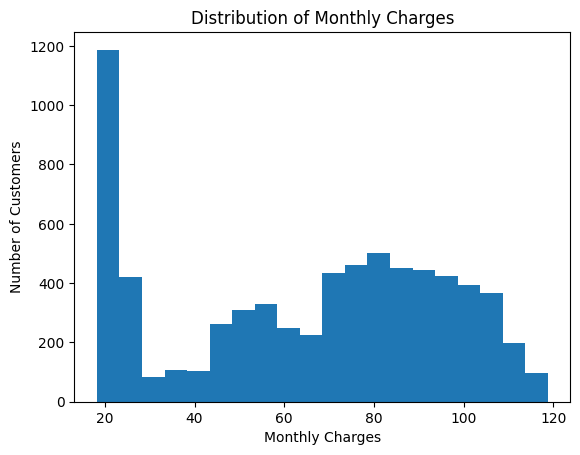

In [19]:
cleaned_df['MonthlyCharges'].plot(kind='hist', bins=20)

plt.title('Distribution of Monthly Charges')
plt.xlabel('Monthly Charges')
plt.ylabel('Number of Customers')
plt.show()

**Interpretation:**  
The MonthlyCharges distribution shows how customer monthly billing amounts are spread across the dataset. The shape of the distribution can reveal whether charges are concentrated around certain price ranges or spread across a wide range.

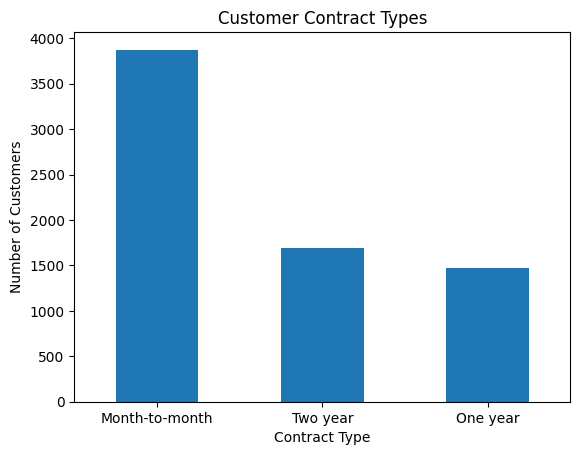

In [20]:
cleaned_df['Contract'].value_counts().plot(kind='bar')

plt.title('Customer Contract Types')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.show()

**Interpretation:**  
The contract distribution shows how customers are divided among month-to-month, one-year, and two-year contracts. The most frequent category represents the contract type used by the largest share of customers.

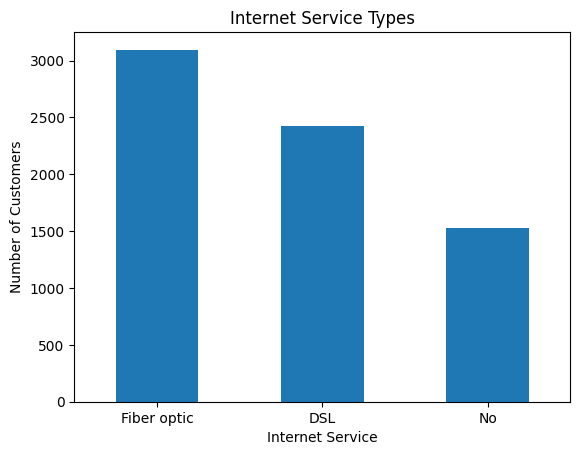

In [21]:
cleaned_df['InternetService'].value_counts().plot(kind='bar')

plt.title('Internet Service Types')
plt.xlabel('Internet Service')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.show()

**Interpretation:**  
The distribution shows the number of customers using DSL, fiber optic, or no internet service. The differences in category frequencies indicate which internet service types are most common in the customer base.

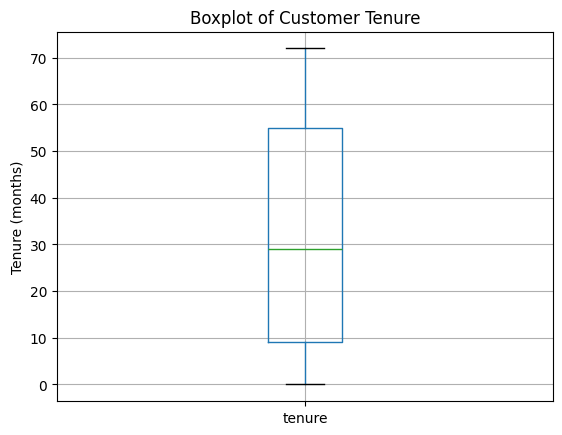

In [22]:
cleaned_df.boxplot(column='tenure')

plt.title('Boxplot of Customer Tenure')
plt.ylabel('Tenure (months)')
plt.show()

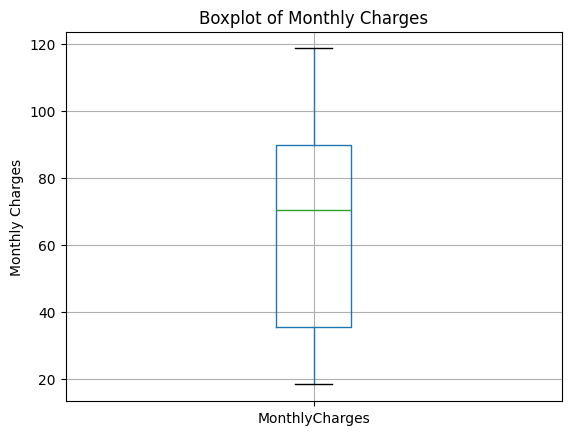

In [23]:
cleaned_df.boxplot(column='MonthlyCharges')

plt.title('Boxplot of Monthly Charges')
plt.ylabel('Monthly Charges')
plt.show()

### Task 13 — Outliers and Skewness

The numerical features were examined using histograms and boxplots to identify unusual values and distribution patterns. Any visible outliers in `tenure` or `MonthlyCharges` should not automatically be considered errors, because they may represent genuine differences between customers, such as customers with longer service histories or more expensive service plans.

In [24]:
churn_summary = pd.DataFrame({
    'Count': cleaned_df['Churn'].value_counts(),
    'Percentage': cleaned_df['Churn'].value_counts(normalize=True) * 100
})

churn_summary

,Count,Percentage
Churn,,
No,5174,73.463013
Yes,1869,26.536987


## Task 14 — Churn **Distribution**

The `Churn` variable contains two classes: `Yes` and `No`. The counts and percentages show that the two classes are not equally represented, with non-churned customers making up the larger proportion of the dataset. Therefore, the target variable is imbalanced.

## Task 15 — Why Class Imbalance Matters

Class imbalance can make a classification model favor the majority class because it appears more frequently in the training data. As a result, a model may achieve high overall accuracy while performing poorly at identifying customers who actually churn, which is the class of particular business interest.

Optional but useful: visualize Churn

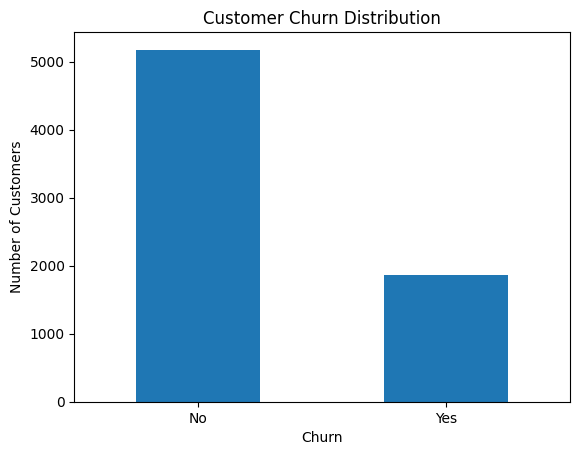

In [25]:
cleaned_df['Churn'].value_counts().plot(kind='bar')

plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.show()

**Interpretation:**  
The bar chart shows that the `No` and `Yes` classes are not equally represented. The larger class corresponds to customers who did not churn, while the smaller class represents customers who churned.

Contract vs Churn (%)


Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83


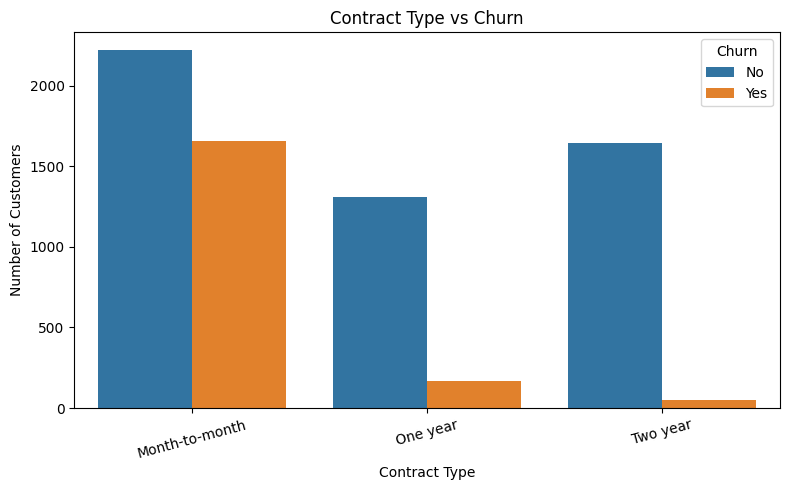

Internet Service vs Churn (%)


Churn,No,Yes
InternetService,,
DSL,81.04,18.96
Fiber optic,58.11,41.89
No,92.60,7.40


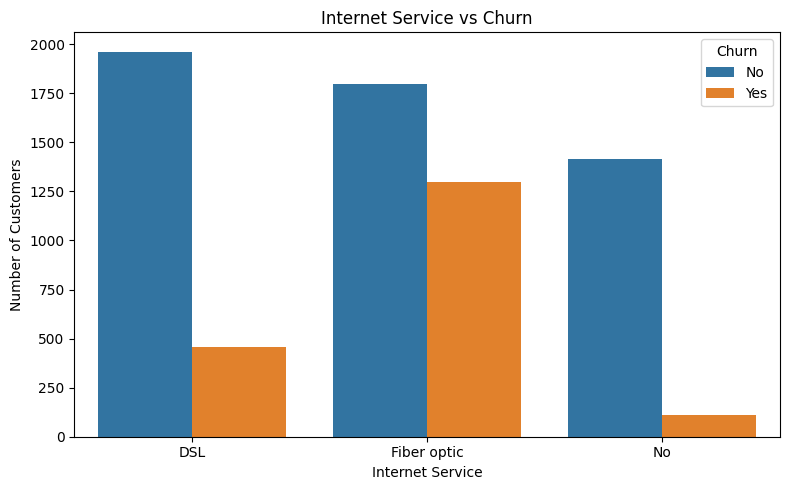

In [26]:
# ============================================
# PART 7 — BIVARIATE ANALYSIS
# TASK 16 — CATEGORICAL FEATURES VS CHURN
# ============================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --------------------------------------------
# 1. Contract vs Churn
# --------------------------------------------

contract_churn = pd.crosstab(
    df['Contract'],
    df['Churn'],
    normalize='index'
) * 100

print("Contract vs Churn (%)")
display(contract_churn.round(2))

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Contract', hue='Churn')
plt.title('Contract Type vs Churn')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


# --------------------------------------------
# 2. InternetService vs Churn
# --------------------------------------------

internet_churn = pd.crosstab(
    df['InternetService'],
    df['Churn'],
    normalize='index'
) * 100

print("Internet Service vs Churn (%)")
display(internet_churn.round(2))

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='InternetService', hue='Churn')
plt.title('Internet Service vs Churn')
plt.xlabel('Internet Service')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

Tenure Summary by Churn


,count,mean,median,min,max
Churn,,,,,
No,5174,37.57,38.0,0,72
Yes,1869,17.98,10.0,1,72


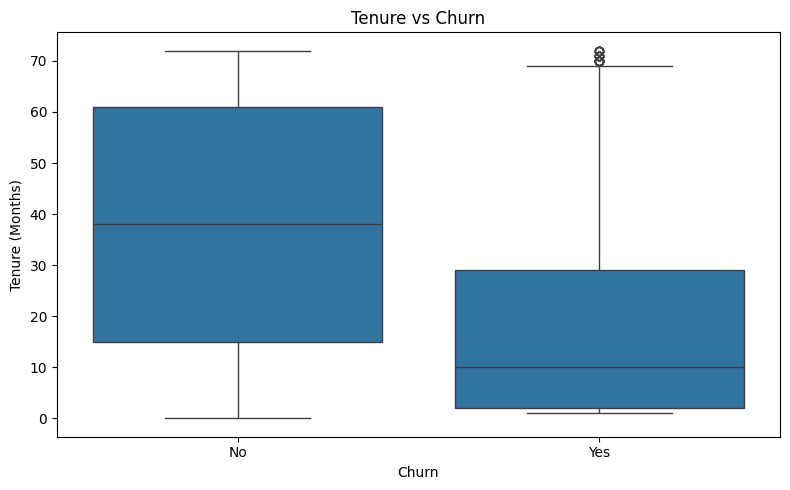

MonthlyCharges Summary by Churn


,count,mean,median,min,max
Churn,,,,,
No,5174,61.27,64.43,18.25,118.75
Yes,1869,74.44,79.65,18.85,118.35


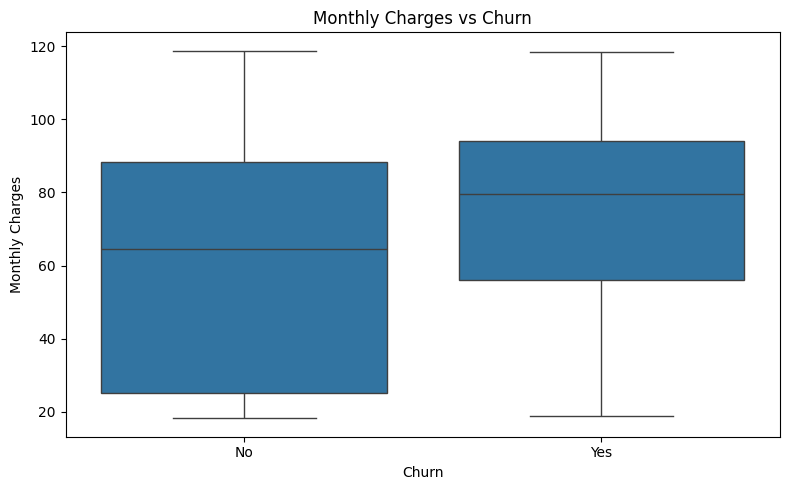

In [27]:
# ============================================
# TASK 17 — NUMERICAL FEATURES VS CHURN
# ============================================

# --------------------------------------------
# 3. Tenure vs Churn
# --------------------------------------------

print("Tenure Summary by Churn")
display(
    df.groupby('Churn')['tenure']
      .agg(['count', 'mean', 'median', 'min', 'max'])
      .round(2)
)

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Churn', y='tenure')
plt.title('Tenure vs Churn')
plt.xlabel('Churn')
plt.ylabel('Tenure (Months)')
plt.tight_layout()
plt.show()


# --------------------------------------------
# 4. MonthlyCharges vs Churn
# --------------------------------------------

print("MonthlyCharges Summary by Churn")
display(
    df.groupby('Churn')['MonthlyCharges']
      .agg(['count', 'mean', 'median', 'min', 'max'])
      .round(2)
)

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges')
plt.title('Monthly Charges vs Churn')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges')
plt.tight_layout()
plt.show()

TotalCharges Summary by Churn


,count,mean,median,min,max
Churn,,,,,
No,5163,2555.34,1683.60,18.80,8672.45
Yes,1869,1531.80,703.55,18.85,8684.80


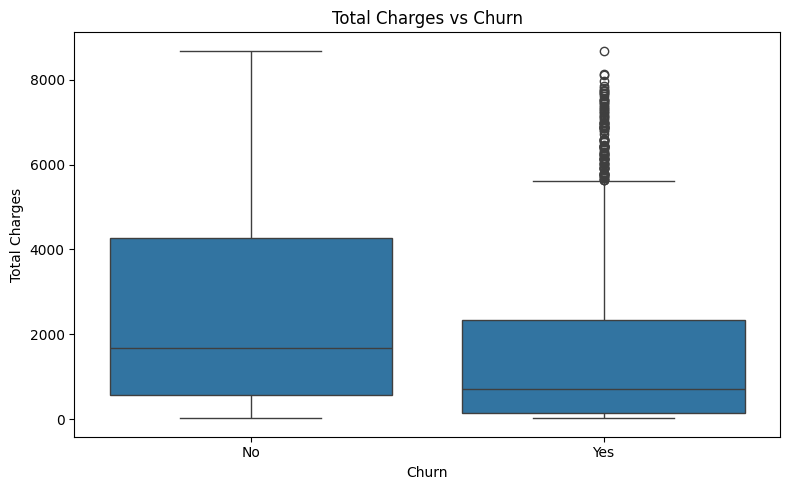

In [28]:
# ============================================
# ADDITIONAL NUMERICAL FEATURE
# TOTALCHARGES VS CHURN
# ============================================

# Convert TotalCharges to numeric for analysis
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print("TotalCharges Summary by Churn")
display(
    df.groupby('Churn')['TotalCharges']
      .agg(['count', 'mean', 'median', 'min', 'max'])
      .round(2)
)

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Churn', y='TotalCharges')
plt.title('Total Charges vs Churn')
plt.xlabel('Churn')
plt.ylabel('Total Charges')
plt.tight_layout()
plt.show()

In [29]:
# ============================================
# TASK 16 & 17 — CHURN RATE TABLES
# ============================================

# Categorical churn rates
categorical_features = [
    'Contract',
    'InternetService',
    'PaymentMethod'
]

for col in categorical_features:
    print(f"\nChurn Rate by {col}")
    churn_rate = pd.crosstab(
        df[col],
        df['Churn'],
        normalize='index'
    ) * 100
    display(churn_rate.round(2))


# Numerical feature means by churn
numerical_features = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges'
]

print("\nNumerical Features by Churn")
display(
    df.groupby('Churn')[numerical_features]
      .mean()
      .round(2)
)


Churn Rate by Contract


Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83



Churn Rate by InternetService


Churn,No,Yes
InternetService,,
DSL,81.04,18.96
Fiber optic,58.11,41.89
No,92.60,7.40



Churn Rate by PaymentMethod


Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.29,16.71
Credit card (automatic),84.76,15.24
Electronic check,54.71,45.29
Mailed check,80.89,19.11



Numerical Features by Churn


,tenure,MonthlyCharges,TotalCharges
Churn,,,
No,37.57,61.27,2555.34
Yes,17.98,74.44,1531.80


Correlation Matrix:


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.00,0.02,0.22,0.10
tenure,0.02,1.00,0.25,0.83
MonthlyCharges,0.22,0.25,1.00,0.65
TotalCharges,0.10,0.83,0.65,1.00


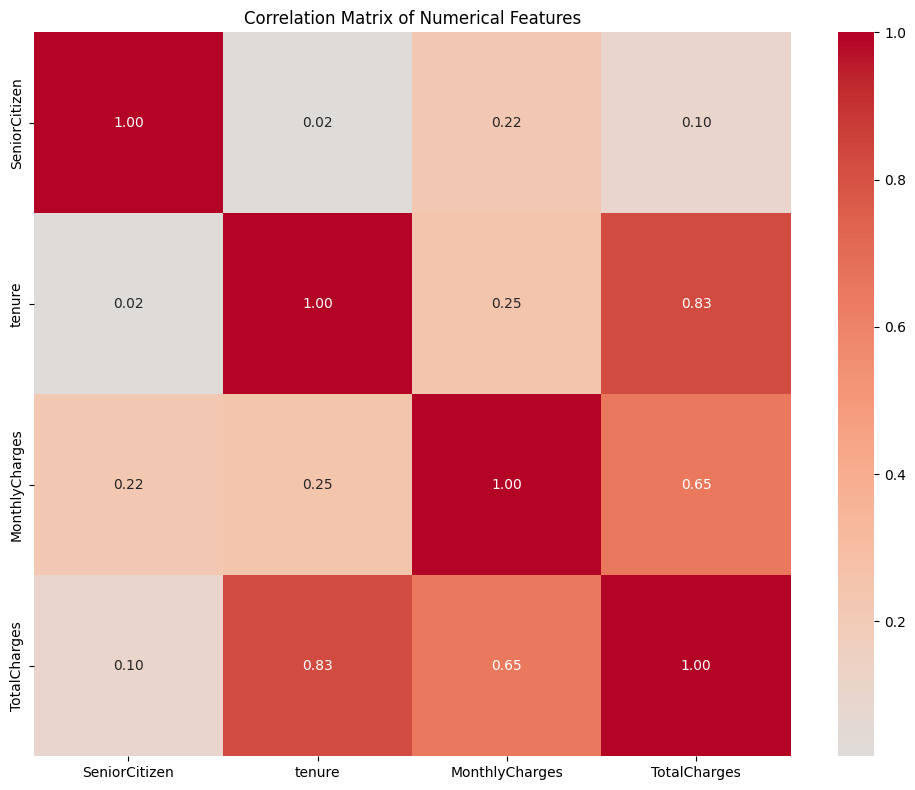

In [30]:
# ============================================
# PART 8 — CORRELATION & FEATURE RELATIONSHIPS
# TASK 18 — CORRELATION MATRIX
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical features
numerical_df = df.select_dtypes(include='number')

# Compute correlation matrix
corr_matrix = numerical_df.corr()

print("Correlation Matrix:")
display(corr_matrix.round(2))

# Visualize correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.show()

In [31]:
# ============================================
# FIND MOST CORRELATED PAIRS
# ============================================

corr_pairs = (
    corr_matrix
    .where(~corr_matrix.eq(1))
    .stack()
    .sort_values(key=abs, ascending=False)
)

print("Most Strongly Correlated Feature Pairs:")
display(corr_pairs.head(10).round(3))

Most Strongly Correlated Feature Pairs:


TotalCharges    tenure            0.826
tenure          TotalCharges      0.826
TotalCharges    MonthlyCharges    0.651
MonthlyCharges  TotalCharges      0.651
tenure          MonthlyCharges    0.248
MonthlyCharges  tenure            0.248
                SeniorCitizen     0.220
SeniorCitizen   MonthlyCharges    0.220
                TotalCharges      0.102
TotalCharges    SeniorCitizen     0.102
dtype: float64

In [33]:
# ============================================
# TASK 19 — CORRELATION ≠ CAUSATION
# ============================================

print("""
Correlation does not imply causation. Two features can be strongly
correlated because they are related to the same underlying factor,
without one directly causing the other.

Highly correlated features may provide redundant information to a
future ML model. This can make interpretation more difficult and,
depending on the algorithm, may cause multicollinearity-related
problems.
""")


Correlation does not imply causation. Two features can be strongly
correlated because they are related to the same underlying factor,
without one directly causing the other.

Highly correlated features may provide redundant information to a
future ML model. This can make interpretation more difficult and,
depending on the algorithm, may cause multicollinearity-related
problems.



In [34]:
# ============================================
# PART 9 — DATA LEAKAGE AWARENESS
# TASK 20
# ============================================

# Display all columns
print("All dataset columns:")
print(df.columns.tolist())

# Check number of unique values in each column
print("\nUnique values per column:")
display(df.nunique().sort_values())

# Check customerID
print("\nCustomer ID unique values:")
print(df['customerID'].nunique())

print("\nTotal rows:")
print(len(df))

All dataset columns:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Unique values per column:


,0
gender,2
SeniorCitizen,2
Partner,2
Dependents,2
PhoneService,2
PaperlessBilling,2
Churn,2
MultipleLines,3
TechSupport,3
StreamingTV,3



Customer ID unique values:
7043

Total rows:
7043


In [ ]:
# ============================================
# TASK 21 — WHAT HAPPENS IF LEAKAGE EXISTS?
# ============================================

print("""
A data-leakage column gives the model information that would not
realistically be available at the time a churn prediction is made.
The model may therefore appear to perform extremely well during
training or evaluation, but its performance would not represent
real-world prediction ability.
""")

In [36]:
# ============================================
# PART 10 — ML-READINESS CHECKLIST
# TASK 22
# ============================================

readiness_data = [
    ['customerID', 'Categorical/Text', 'Identifier', 'Remove',
     'Identifier only; does not provide useful predictive information.'],

    ['gender', 'Categorical', 'Feature', 'Keep',
     'Customer demographic information that may contain predictive patterns.'],

    ['SeniorCitizen', 'Numerical/Binary', 'Feature', 'Keep',
     'Represents whether the customer is a senior citizen and may relate to churn.'],

    ['Partner', 'Categorical', 'Feature', 'Keep',
     'Relationship status may be associated with customer retention.'],

    ['Dependents', 'Categorical', 'Feature', 'Keep',
     'Dependent status may be related to customer behavior and churn.'],

    ['tenure', 'Numerical', 'Feature', 'Keep',
     'Represents how long the customer has stayed with the company.'],

    ['PhoneService', 'Categorical', 'Feature', 'Keep',
     'Indicates whether the customer subscribes to phone service.'],

    ['MultipleLines', 'Categorical', 'Feature', 'Keep',
     "Describes the customer's phone-line subscription."],

    ['InternetService', 'Categorical', 'Feature', 'Keep',
     'Internet service type may be strongly associated with churn.'],

    ['OnlineSecurity', 'Categorical', 'Feature', 'Keep',
     'Indicates whether the customer has online security service.'],

    ['OnlineBackup', 'Categorical', 'Feature', 'Keep',
     'Indicates whether the customer has online backup service.'],

    ['DeviceProtection', 'Categorical', 'Feature', 'Keep',
     'Indicates whether the customer has device protection.'],

    ['TechSupport', 'Categorical', 'Feature', 'Keep',
     'Indicates whether the customer has technical support service.'],

    ['StreamingTV', 'Categorical', 'Feature', 'Keep',
     'Indicates whether the customer uses streaming TV service.'],

    ['StreamingMovies', 'Categorical', 'Feature', 'Keep',
     'Indicates whether the customer uses streaming movie service.'],

    ['Contract', 'Categorical', 'Feature', 'Keep',
     'Contract type can strongly influence customer retention.'],

    ['PaperlessBilling', 'Categorical', 'Feature', 'Keep',
     'Billing preference may be associated with customer behavior.'],

    ['PaymentMethod', 'Categorical', 'Feature', 'Keep',
     'Payment method may show differences in churn behavior.'],

    ['MonthlyCharges', 'Numerical', 'Feature', 'Keep',
     'Monthly spending may be associated with churn.'],

    ['TotalCharges', 'Numerical', 'Feature', 'Keep after cleaning',
     'Represents total amount charged and must be converted to numeric and missing values handled.'],

    ['Churn', 'Categorical', 'Target', 'Keep as target only',
     'This is the variable we want to predict; it must not be used as an input feature.']
]

# Create DataFrame
readiness_df = pd.DataFrame(
    readiness_data,
    columns=['Column', 'Type', 'Role', 'Action', 'Reason']
)

# Display table
display(readiness_df)

,Column,Type,Role,Action,Reason
0,customerID,Categorical/Text,Identifier,Remove,Identifier only; does not provide useful predi...
1,gender,Categorical,Feature,Keep,Customer demographic information that may cont...
2,SeniorCitizen,Numerical/Binary,Feature,Keep,Represents whether the customer is a senior ci...
3,Partner,Categorical,Feature,Keep,Relationship status may be associated with cus...
4,Dependents,Categorical,Feature,Keep,Dependent status may be related to customer be...
5,tenure,Numerical,Feature,Keep,Represents how long the customer has stayed wi...
6,PhoneService,Categorical,Feature,Keep,Indicates whether the customer subscribes to p...
7,MultipleLines,Categorical,Feature,Keep,Describes the customer's phone-line subscription.
8,InternetService,Categorical,Feature,Keep,Internet service type may be strongly associat...
9,OnlineSecurity,Categorical,Feature,Keep,Indicates whether the customer has online secu...


In [37]:
# ============================================
# VERIFY ALL DATASET COLUMNS ARE INCLUDED
# ============================================

print("Dataset columns:")
print(df.columns.tolist())

print("\nColumns in ML-readiness table:")
print(readiness_df['Column'].tolist())

missing_from_table = set(df.columns) - set(readiness_df['Column'])
extra_in_table = set(readiness_df['Column']) - set(df.columns)

print("\nMissing columns from readiness table:")
print(missing_from_table)

print("\nExtra columns in readiness table:")
print(extra_in_table)

Dataset columns:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Columns in ML-readiness table:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Missing columns from readiness table:
set()

Extra columns in readiness table:
set()


In [38]:
# Save ML-readiness table
readiness_df.to_csv('ml_readiness_table.csv', index=False)

print("ML-readiness table saved as ml_readiness_table.csv")

ML-readiness table saved as ml_readiness_table.csv


In [40]:
# ============================================
# PART 11 — BUILDING THE CLEAN DATASET
# TASK 23
# ============================================

# Create a copy so the original dataframe remains unchanged
clean_df = df.copy()

# --------------------------------------------
# 1. Remove the identifier column
# --------------------------------------------

clean_df = clean_df.drop(columns=['customerID'])

# --------------------------------------------
# 2. Convert TotalCharges to numeric
# --------------------------------------------

clean_df['TotalCharges'] = pd.to_numeric(
    clean_df['TotalCharges'],
    errors='coerce'
)

# --------------------------------------------
# 3. Handle missing TotalCharges values
# --------------------------------------------

print("Missing TotalCharges before handling:")
print(clean_df['TotalCharges'].isnull().sum())

# Fill missing TotalCharges using 0
clean_df['TotalCharges'] = clean_df['TotalCharges'].fillna(0)

print("\nMissing TotalCharges after handling:")
print(clean_df['TotalCharges'].isnull().sum())

# --------------------------------------------
# 4. Remove duplicate rows
# --------------------------------------------

print("\nDuplicate rows before removal:")
print(clean_df.duplicated().sum())

clean_df = clean_df.drop_duplicates()

print("Duplicate rows after removal:")
print(clean_df.duplicated().sum())

# --------------------------------------------
# 5. Save the cleaned dataset
# --------------------------------------------

clean_df.to_csv('clean_churn.csv', index=False)

print("\nClean dataset saved as: clean_churn.csv")

# --------------------------------------------
# 6. Display final shape
# --------------------------------------------

print("\nFinal clean dataset shape:")
print(clean_df.shape)

display(clean_df.head())

Missing TotalCharges before handling:
11

Missing TotalCharges after handling:
0

Duplicate rows before removal:
22
Duplicate rows after removal:
0

Clean dataset saved as: clean_churn.csv

Final clean dataset shape:
(7021, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [41]:
# ============================================
# TASK 24 — FINAL DATASET CHECK
# ============================================

print("Final Clean Dataset Information:")
clean_df.info()

Final Clean Dataset Information:
<class 'pandas.core.frame.DataFrame'>
Index: 7021 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7021 non-null   object 
 1   SeniorCitizen     7021 non-null   int64  
 2   Partner           7021 non-null   object 
 3   Dependents        7021 non-null   object 
 4   tenure            7021 non-null   int64  
 5   PhoneService      7021 non-null   object 
 6   MultipleLines     7021 non-null   object 
 7   InternetService   7021 non-null   object 
 8   OnlineSecurity    7021 non-null   object 
 9   OnlineBackup      7021 non-null   object 
 10  DeviceProtection  7021 non-null   object 
 11  TechSupport       7021 non-null   object 
 12  StreamingTV       7021 non-null   object 
 13  StreamingMovies   7021 non-null   object 
 14  Contract          7021 non-null   object 
 15  PaperlessBilling  7021 non-null   object 
 16  PaymentMethod 

In [42]:
# Final missing-value check
print("\nMissing values in clean_df:")
display(clean_df.isnull().sum())

# Final duplicate check
print("\nDuplicate rows in clean_df:")
print(clean_df.duplicated().sum())


Missing values in clean_df:


,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0



Duplicate rows in clean_df:
0


In [43]:
# Final missing-value check
print("\nMissing values in clean_df:")
display(clean_df.isnull().sum())

# Final duplicate check
print("\nDuplicate rows in clean_df:")
print(clean_df.duplicated().sum())


Missing values in clean_df:


,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0



Duplicate rows in clean_df:
0


# Part 12 — Key Findings & Final Reflection

## Five Key Findings

### Finding 1: Customer Churn is Imbalanced

**Observation:**  
The dataset contains more non-churned customers than churned customers.

**Evidence:**  
The `Churn` distribution shows that the `No` class has a higher count and percentage than the `Yes` class.

**Interpretation:**  
The target variable is imbalanced, meaning churned customers represent a smaller portion of the dataset.

---

### Finding 2: Contract Type is Associated with Churn

**Observation:**  
Customers with different contract types have noticeably different churn rates.

**Evidence:**  
The `Contract` vs `Churn` analysis showed different percentages of churn across the contract categories.

**Interpretation:**  
Contract duration and type may influence customer retention, with some contract groups appearing more likely to churn than others.

---

### Finding 3: Tenure is Related to Churn

**Observation:**  
Churned and non-churned customers show differences in their tenure distributions.

**Evidence:**  
The boxplot and summary statistics for `tenure` showed different central values and distributions across the two churn classes.

**Interpretation:**  
Customers who have been with the company for different lengths of time may have different levels of churn risk.

---

### Finding 4: Monthly Charges are Associated with Churn

**Observation:**  
The distribution of `MonthlyCharges` differs between churned and non-churned customers.

**Evidence:**  
The `MonthlyCharges` boxplot and group summary showed differences between the two churn groups.

**Interpretation:**  
Monthly charges may be an important feature for understanding customer churn behavior.

---

### Finding 5: CustomerID Should Not Be Used as a Predictive Feature

**Observation:**  
`customerID` uniquely identifies customers but does not describe their behavior or characteristics.

**Evidence:**  
The number of unique customer IDs corresponds to individual customers, making it an identifier rather than a meaningful predictive variable.

**Interpretation:**  
`customerID` should be removed from the model inputs because it does not provide useful information for predicting churn and could lead to meaningless patterns.

## Final Reflection

### 1. What was the most important data-quality issue you found?

The most important data-quality issue was the missing and incorrectly typed `TotalCharges` values. The column was stored as an object even though it represents a numerical quantity, so it needed to be converted to numeric and the missing values needed to be handled before machine learning.

### 2. What was the most interesting pattern you discovered?

The most interesting pattern was that churn rates differed substantially across customer groups, particularly across contract types. This suggests that the nature of a customer's contract may be strongly related to their likelihood of leaving the company.

### 3. Which feature seems most useful for predicting churn?

`Contract` appears to be one of the most useful features because the churn rate varies considerably between contract categories. Other potentially useful features include `tenure` and `MonthlyCharges`.

### 4. Which feature should probably not be used, and why?

`customerID` should not be used because it is simply an identifier. It does not represent a meaningful customer characteristic and should therefore be removed before model training.

### 5. What preprocessing will be required before ML modeling?

Before modeling, categorical features will need to be converted into a numerical representation, numerical features may need appropriate scaling depending on the algorithm, and the target variable will need to be prepared for classification. The training and testing data should also be separated before model training.

### 6. What would you do next if you had another 3 hours?

I would investigate the strongest churn-related features in more detail, examine additional customer segments, perform feature engineering where appropriate, and prepare the dataset for the classification task in Lab 3.

In [45]:
import os

print("clean_churn.csv exists:", os.path.exists("clean_churn.csv"))
print("ml_readiness_table.csv exists:", os.path.exists("ml_readiness_table.csv"))

print("\nFinal clean dataset shape:")
print(clean_df.shape)

print("\nFinal columns:")
print(clean_df.columns.tolist())

clean_churn.csv exists: True
ml_readiness_table.csv exists: True

Final clean dataset shape:
(7021, 20)

Final columns:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [46]:
import os

print("Notebook-related files in current directory:")

for file in os.listdir():
    print(file)

Notebook-related files in current directory:
.config
clean_churn.csv
WA_Fn-UseC_-Telco-Customer-Churn.csv
ml_readiness_table.csv
sample_data
